In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

data = np.load("/content/drive/MyDrive/MachineLearning/datasets/lab7/chestmnist_64.npz")

print("Keys in the dataset:", data.keys())

# Assuming 'data' contains image and label arrays, let's inspect their shapes
for key in data.keys():
    print(f"Shape of '{key}': {data[key].shape}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Keys in the dataset: KeysView(NpzFile '/content/drive/MyDrive/MachineLearning/datasets/lab7/chestmnist_64.npz' with keys: train_images, train_labels, val_images, val_labels, test_images...)
Shape of 'train_images': (78468, 64, 64)
Shape of 'train_labels': (78468, 14)
Shape of 'val_images': (11219, 64, 64)
Shape of 'val_labels': (11219, 14)
Shape of 'test_images': (22433, 64, 64)
Shape of 'test_labels': (22433, 14)


In [ ]:
train_labels = data['train_labels']

# Sum the occurrences of each label
label_counts = np.sum(train_labels, axis=0)

print("Distribución de las etiquetas en train_labels:")
for i, count in enumerate(label_counts):
    print(f"Label {i+1}: {count} ocurrencias")


Distribución de las etiquetas en train_labels:
Label 1: 7996 ocurrencias
Label 2: 1950 ocurrencias
Label 3: 9261 ocurrencias
Label 4: 13914 ocurrencias
Label 5: 3988 ocurrencias
Label 6: 4375 ocurrencias
Label 7: 978 ocurrencias
Label 8: 3705 ocurrencias
Label 9: 3263 ocurrencias
Label 10: 1690 ocurrencias
Label 11: 1799 ocurrencias
Label 12: 1158 ocurrencias
Label 13: 2279 ocurrencias
Label 14: 144 ocurrencias


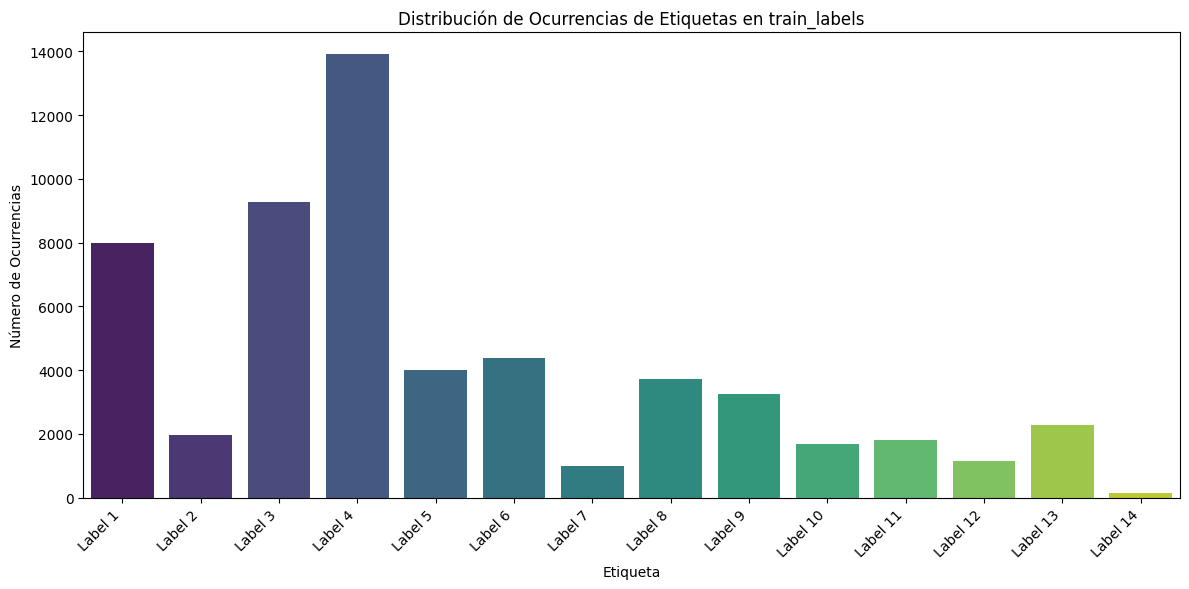

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a list of label names for better readability (assuming generic labels 1 to 14)
label_names = [f'Label {i+1}' for i in range(len(label_counts))]

plt.figure(figsize=(12, 6))
sns.barplot(x=label_names, y=label_counts, palette='viridis', hue=label_names, legend=False)
plt.title('Distribución de Ocurrencias de Etiquetas en train_labels')
plt.xlabel('Etiqueta')
plt.ylabel('Número de Ocurrencias')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

Número de imágenes con la Etiqueta 14: 144

Mostrando ejemplos de aumento de datos para la Etiqueta 14:


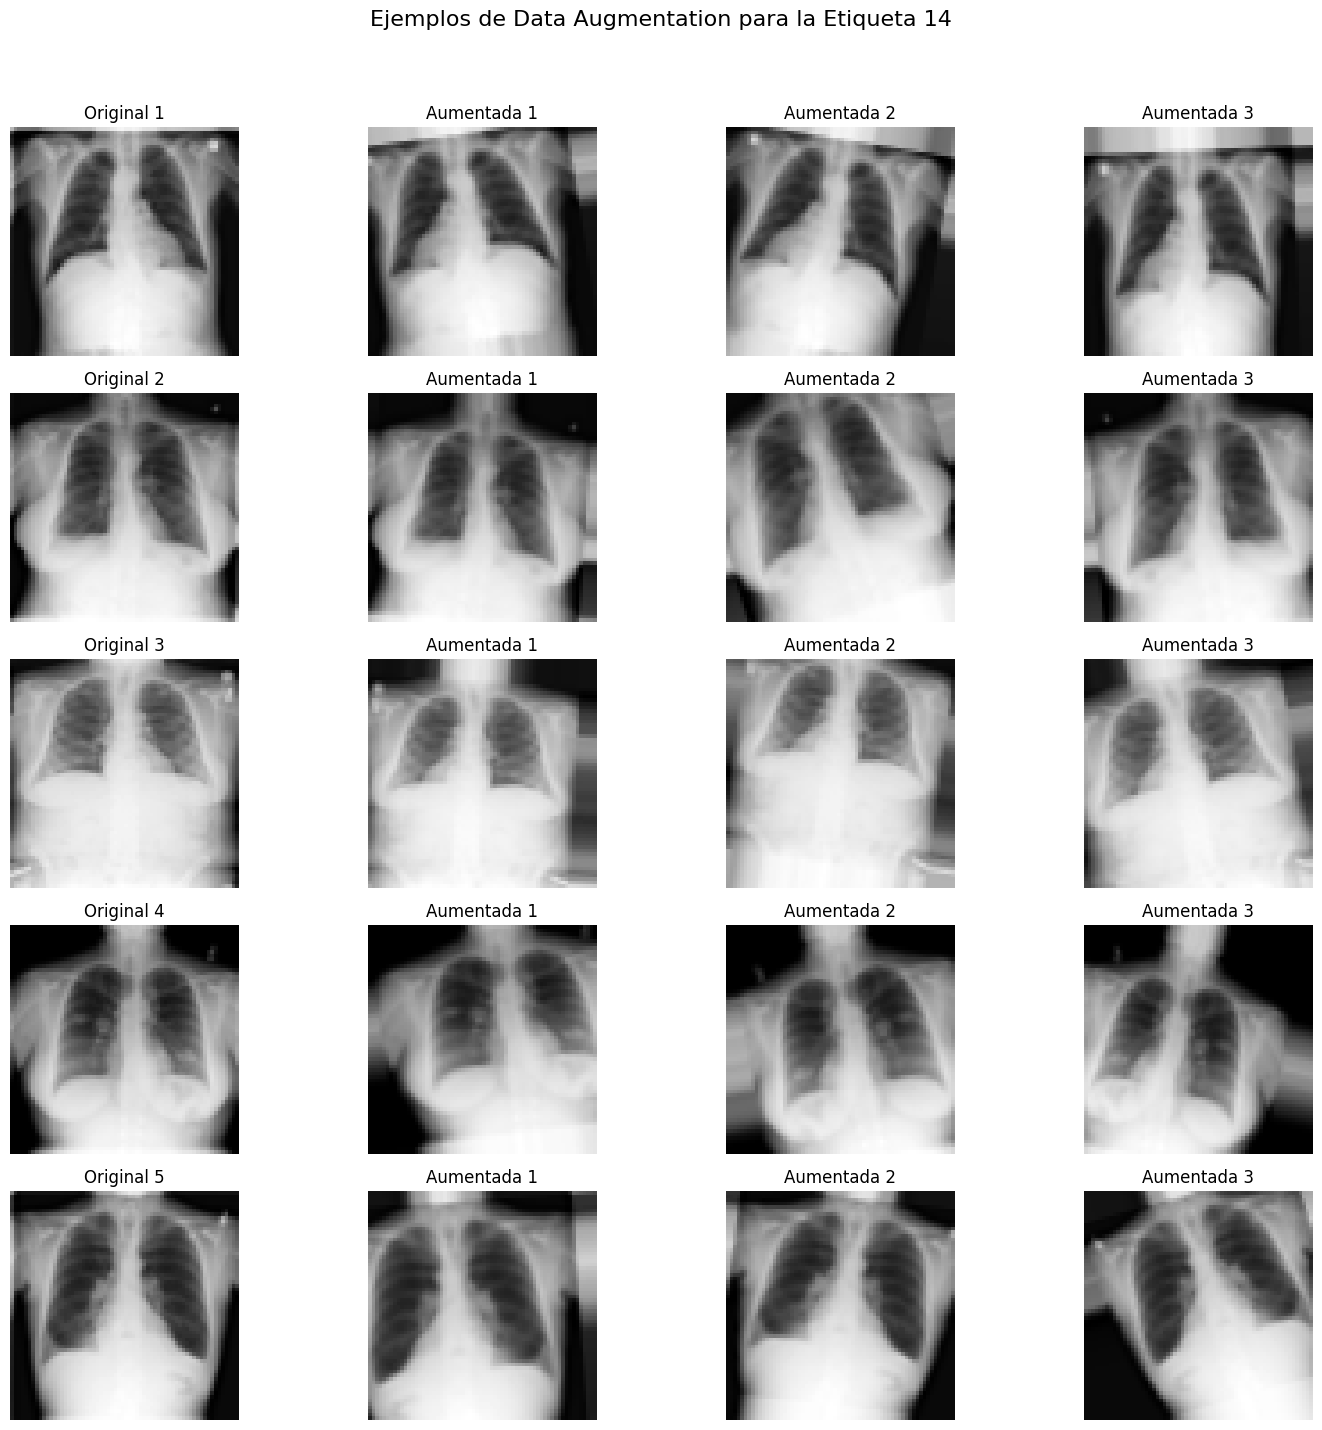

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Identificar las imágenes con la Etiqueta 14 ---
# La Etiqueta 14 corresponde a la columna 13 en train_labels (índice 0-basado)
label_14_index = 13

# Obtener las imágenes y etiquetas de entrenamiento
train_images = data['train_images']
train_labels = data['train_labels']

# Encontrar los índices de las imágenes donde la Etiqueta 14 está presente (valor es 1)
indices_label_14 = np.where(train_labels[:, label_14_index] == 1)[0]

# Seleccionar solo las imágenes que contienen la Etiqueta 14
images_label_14 = train_images[indices_label_14]

print(f"Número de imágenes con la Etiqueta 14: {len(images_label_14)}")

# Asegurarse de que las imágenes tengan el formato correcto para ImageDataGenerator (añadir canal si es necesario)
# Las imágenes son (num_samples, height, width), ImageDataGenerator espera (num_samples, height, width, channels)
if len(images_label_14.shape) == 3:
    images_label_14 = np.expand_dims(images_label_14, axis=-1) # Añadir un canal para imágenes en escala de grises

# --- 2. Configurar el ImageDataGenerator ---
# Puedes ajustar estos parámetros para generar diferentes variaciones
datagen = ImageDataGenerator(
    rotation_range=20,        # Rotar imágenes en un rango de 20 grados
    width_shift_range=0.1,    # Desplazar horizontalmente hasta un 10% del ancho
    height_shift_range=0.1,   # Desplazar verticalmente hasta un 10% del alto
    shear_range=0.1,          # Aplicar cizallamiento (shear) de hasta 10 grados
    zoom_range=0.1,           # Aplicar zoom de hasta 10%
    horizontal_flip=True,     # Voltear imágenes horizontalmente
    fill_mode='nearest'       # Estrategia para rellenar píxeles nuevos después de transformaciones
)

# --- 3. Aplicar y mostrar algunas imágenes aumentadas ---
print("\nMostrando ejemplos de aumento de datos para la Etiqueta 14:")

# Seleccionar unas pocas imágenes de muestra de la Etiqueta 14 para visualizar
sample_images = images_label_14[:5] # Tomar las primeras 5 imágenes como ejemplo

fig, axes = plt.subplots(nrows=len(sample_images), ncols=4, figsize=(15, 3 * len(sample_images)))
fig.suptitle('Ejemplos de Data Augmentation para la Etiqueta 14', fontsize=16)

for i, img in enumerate(sample_images):
    # Imagen original
    axes[i, 0].imshow(img.squeeze(), cmap='gray')
    axes[i, 0].set_title(f'Original {i+1}')
    axes[i, 0].axis('off')

    # Generar y mostrar 3 versiones aumentadas
    # flow() espera (num_samples, height, width, channels), por eso expand_dims
    # y luego toma el primer lote (batch) generado.
    for j, augmented_img in enumerate(datagen.flow(np.expand_dims(img, axis=0), batch_size=1)):
        if j >= 3: # Solo queremos 3 imágenes aumentadas por original
            break
        axes[i, j+1].imshow(augmented_img[0].squeeze(), cmap='gray')
        axes[i, j+1].set_title(f'Aumentada {j+1}')
        axes[i, j+1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para título
plt.show()


### Aplicar aumento de datos a otras etiquetas con pocas ocurrencias

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Obtener los datos originales de entrenamiento
original_train_images = data['train_images']
original_train_labels = data['train_labels']

# Asegurarse de que las imágenes tengan el formato correcto (num_samples, height, width, channels)
if len(original_train_images.shape) == 3:
    original_train_images = np.expand_dims(original_train_images, axis=-1)

# Configurar el ImageDataGenerator (usamos los mismos parámetros que antes)
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Definir las etiquetas a aumentar y el número de imágenes originales en cada una
# (Label 14 ya fue procesada, pero la incluimos para un enfoque general si se quisiera reprocesar)
# Revisa la salida de label_counts para ajustar el target_count si lo deseas

# Las etiquetas son 0-indexadas, por lo que Label 7 es índice 6, Label 12 es índice 11, etc.
labels_to_augment_indices = {
    6: label_counts[6],   # Label 7: 978
    11: label_counts[11], # Label 12: 1158
    9: label_counts[9],   # Label 10: 1690
    1: label_counts[1],   # Label 2: 1950
    10: label_counts[10], # Label 11: 1799
    12: label_counts[12], # Label 13: 2279
    13: label_counts[13]  # Label 14: 144
}

augmented_images_list = []
augmented_labels_list = []

print("Iniciando aumento de datos para etiquetas con pocas ocurrencias...")

for label_idx, original_count in labels_to_augment_indices.items():
    # Encontrar los índices de las imágenes donde esta etiqueta está presente
    indices = np.where(original_train_labels[:, label_idx] == 1)[0]
    images_for_augmentation = original_train_images[indices]

    # Si no hay imágenes para esta etiqueta, continuar
    if len(images_for_augmentation) == 0:
        print(f"No se encontraron imágenes para la Etiqueta {label_idx + 1}. Saltando.")
        continue

    # Establecer el factor de aumento. Mayor para Label 14.
    current_augmentation_factor = 2
    if label_idx == 13: # Para la Etiqueta 14 (índice 13)
        current_augmentation_factor = 20 # Aumentamos a 20 veces las imágenes originales

    num_images_to_generate = original_count * current_augmentation_factor

    print(f"Etiqueta {label_idx + 1}: Originales = {original_count}, Factor de aumento = {current_augmentation_factor}, Generando = {num_images_to_generate} imágenes aumentadas.")

    # Usar flow() para generar las imágenes aumentadas
    i = 0
    # Asegurarse de que el lote sea lo suficientemente grande para todas las imágenes de esta etiqueta
    # o que se genere un generador iterativo.
    # Para simplificar y evitar problemas de memoria con lotes muy grandes, generaremos una a una si hay muchas.
    # Pero es más eficiente si el batch_size es grande.
    # Si images_for_augmentation es grande, datagen.flow() podría generar un iterador infinito.
    # Aquí, limitamos la generación al current_augmentation_factor * original_count

    generated_count = 0
    for batch in datagen.flow(images_for_augmentation, batch_size=len(images_for_augmentation), shuffle=False):
        if i >= current_augmentation_factor:
            break

        # Asegurarse de que el batch tiene la forma correcta (num_samples, H, W, C)
        augmented_images_list.append(batch)
        # Las etiquetas para las imágenes aumentadas son las mismas que sus originales
        augmented_labels_list.append(original_train_labels[indices])
        i += 1


# Concatenar todas las imágenes y etiquetas aumentadas
if augmented_images_list:
    all_augmented_images = np.concatenate(augmented_images_list, axis=0)
    all_augmented_labels = np.concatenate(augmented_labels_list, axis=0)

    print(f"Total de imágenes aumentadas generadas: {len(all_augmented_images)}")

    # Combinar las imágenes y etiquetas originales con las aumentadas
    new_train_images = np.concatenate([original_train_images, all_augmented_images], axis=0)
    new_train_labels = np.concatenate([original_train_labels, all_augmented_labels], axis=0)
else:
    print("No se generaron imágenes aumentadas.")
    new_train_images = original_train_images
    new_train_labels = original_train_labels


print(f"Forma del nuevo train_images: {new_train_images.shape}")
print(f"Forma del nuevo train_labels: {new_train_labels.shape}")

# Verificar la nueva distribución de las etiquetas aumentadas
new_label_counts = np.sum(new_train_labels, axis=0)
print("\nNueva distribución de las etiquetas en el conjunto de entrenamiento (incluyendo aumentadas):")
for i, count in enumerate(new_label_counts):
    print(f"Label {i+1}: {count} ocurrencias")

Iniciando aumento de datos para etiquetas con pocas ocurrencias...
Etiqueta 7: Originales = 978, Factor de aumento = 2, Generando = 1956 imágenes aumentadas.
Etiqueta 12: Originales = 1158, Factor de aumento = 2, Generando = 2316 imágenes aumentadas.
Etiqueta 10: Originales = 1690, Factor de aumento = 2, Generando = 3380 imágenes aumentadas.
Etiqueta 2: Originales = 1950, Factor de aumento = 2, Generando = 3900 imágenes aumentadas.
Etiqueta 11: Originales = 1799, Factor de aumento = 2, Generando = 3598 imágenes aumentadas.
Etiqueta 13: Originales = 2279, Factor de aumento = 2, Generando = 4558 imágenes aumentadas.
Etiqueta 14: Originales = 144, Factor de aumento = 20, Generando = 2880 imágenes aumentadas.
Total de imágenes aumentadas generadas: 22588
Forma del nuevo train_images: (101056, 64, 64, 1)
Forma del nuevo train_labels: (101056, 14)

Nueva distribución de las etiquetas en el conjunto de entrenamiento (incluyendo aumentadas):
Label 1: 11286 ocurrencias
Label 2: 6434 ocurrencias

### Guardar el dataset procesado

In [ ]:
# Definir la ruta donde se guardará el nuevo dataset
save_path = "/content/drive/MyDrive/MachineLearning/datasets/lab7/chestmnist_64a.npz"

# Preparar el diccionario con todos los datos que queremos guardar
# Asumimos que queremos mantener val y test sin cambios, solo aumentar train.
dataset_to_save = {
    'train_images': new_train_images.squeeze(), # Remove the channel dimension if it was added for augmentation
    'train_labels': new_train_labels,
    'val_images': data['val_images'],
    'val_labels': data['val_labels'],
    'test_images': data['test_images'],
    'test_labels': data['test_labels'],
}

# Guardar el dataset en formato .npz
np.savez_compressed(save_path, **dataset_to_save)

print(f"Dataset aumentado y guardado en: {save_path}")

# Opcional: Cargar y verificar para confirmar que se guardó correctamente
# loaded_data = np.load(save_path)
# print("\nVerificación de carga:")
# for key in loaded_data.keys():
#     print(f"Key: {key}, Shape: {loaded_data[key].shape}")


Dataset aumentado y guardado en: /content/drive/MyDrive/MachineLearning/datasets/lab7/chestmnist_64a.npz


### Nuevo Análisis del Dataset Aumentado

In [ ]:
print("\n--- Formas del Dataset Actualizado ---")
print(f"Forma de train_images: {new_train_images.shape}")
print(f"Forma de train_labels: {new_train_labels.shape}")
print(f"Forma de val_images: {data['val_images'].shape}")
print(f"Forma de val_labels: {data['val_labels'].shape}")
print(f"Forma de test_images: {data['test_images'].shape}")
print(f"Forma de test_labels: {data['test_labels'].shape}")

print("\n--- Nueva Distribución de Etiquetas (train_labels) ---")
# new_label_counts ya está calculado en el paso anterior, solo lo imprimimos de nuevo
for i, count in enumerate(new_label_counts):
    print(f"Label {i+1}: {count} ocurrencias")



--- Formas del Dataset Actualizado ---
Forma de train_images: (101056, 64, 64, 1)
Forma de train_labels: (101056, 14)
Forma de val_images: (11219, 64, 64)
Forma de val_labels: (11219, 14)
Forma de test_images: (22433, 64, 64)
Forma de test_labels: (22433, 14)

--- Nueva Distribución de Etiquetas (train_labels) ---
Label 1: 11286 ocurrencias
Label 2: 6434 ocurrencias
Label 3: 14157 ocurrencias
Label 4: 19612 ocurrencias
Label 5: 5782 ocurrencias
Label 6: 5839 ocurrencias
Label 7: 3628 ocurrencias
Label 8: 5589 ocurrencias
Label 9: 4599 ocurrencias
Label 10: 5940 ocurrencias
Label 11: 5821 ocurrencias
Label 12: 3950 ocurrencias
Label 13: 7717 ocurrencias
Label 14: 3058 ocurrencias


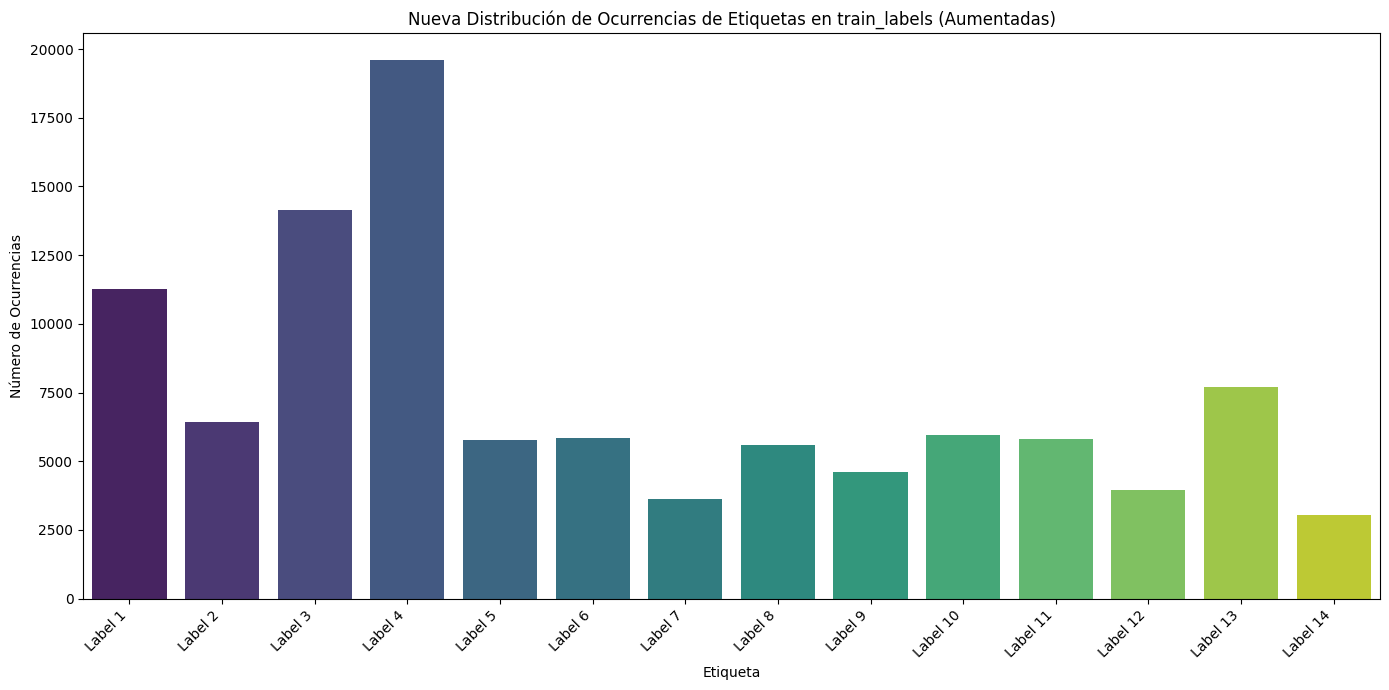

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a list of label names for better readability
label_names_augmented = [f'Label {i+1}' for i in range(len(new_label_counts))]

plt.figure(figsize=(14, 7))
sns.barplot(x=label_names_augmented, y=new_label_counts, palette='viridis', hue=label_names_augmented, legend=False)
plt.title('Nueva Distribución de Ocurrencias de Etiquetas en train_labels (Aumentadas)')
plt.xlabel('Etiqueta')
plt.ylabel('Número de Ocurrencias')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Calcular el ratio de train, test y val
num_train_samples = len(new_train_images)
num_val_samples = len(data['val_images'])
num_test_samples = len(data['test_images'])

total_samples = num_train_samples + num_val_samples + num_test_samples

ratio_train = (num_train_samples / total_samples) * 100
ratio_val = (num_val_samples / total_samples) * 100
ratio_test = (num_test_samples / total_samples) * 100

print("\n--- Ratio de Particiones del Dataset ---")
print(f"Total de muestras: {total_samples}")
print(f"Train: {num_train_samples} muestras ({ratio_train:.2f}%)")
print(f"Validation: {num_val_samples} muestras ({ratio_val:.2f}%)")
print(f"Test: {num_test_samples} muestras ({ratio_test:.2f}%)")



--- Ratio de Particiones del Dataset ---
Total de muestras: 132548
Train: 98896 muestras (74.61%)
Validation: 11219 muestras (8.46%)
Test: 22433 muestras (16.92%)
